# 1.0 Exploratory Data Analysis — Scrabble Player Rating

Exploration of the Scrabble player-rating dataset (`games`, `turns`, `train`) with the goal of
understanding which game- and turn-level features carry signal about a player's rating.


## 1.1 Setup and Imports

In [458]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


## 1.2 Loading the Data

Three source files:
- `games.csv` — one row per game (settings, timing, outcome).
- `turns.csv` — one row per turn (rack, move, points, running score).
- `train.csv` — one row per player per game, with the target `rating`.

In [459]:
games_df = pd.read_csv("scrabble-player-rating-data/games.csv")
turns_df = pd.read_csv("scrabble-player-rating-data/turns.csv")
train_df = pd.read_csv("scrabble-player-rating-data/train.csv")

## 1.3 Games Dataset

In [460]:
games_df.head()

,game_id,first,time_control_name,game_end_reason,winner,created_at,lexicon,initial_time_seconds,increment_seconds,rating_mode,max_overtime_minutes,game_duration_seconds
0,1,BetterBot,regular,STANDARD,1,2022-08-26 03:38:49,NWL20,1200,0,CASUAL,1,674.844274
1,2,Super,regular,STANDARD,1,2022-08-10 19:19:59,CSW21,3600,0,RATED,1,364.214418
2,3,BetterBot,regular,STANDARD,1,2022-09-04 08:04:27,CSW21,900,0,RATED,5,492.268262
3,4,BetterBot,regular,RESIGNED,0,2022-09-12 02:36:19,CSW21,3600,0,CASUAL,1,350.861141
4,5,STEEBot,regular,STANDARD,0,2022-09-06 04:31:36,NWL20,1200,0,CASUAL,1,642.688722


In [461]:
games_df["max_overtime_seconds"] = games_df["max_overtime_minutes"] * 60
games_df['created_at'] = pd.to_datetime(games_df['created_at'])

games_df['year'] = games_df['created_at'].dt.year
games_df['month'] = games_df['created_at'].dt.month
games_df['day'] = games_df['created_at'].dt.day
games_df['hour'] = games_df['created_at'].dt.hour
games_df.head()

,game_id,first,time_control_name,game_end_reason,winner,created_at,lexicon,initial_time_seconds,increment_seconds,rating_mode,max_overtime_minutes,game_duration_seconds,max_overtime_seconds,year,month,day,hour
0,1,BetterBot,regular,STANDARD,1,2022-08-26 03:38:49,NWL20,1200,0,CASUAL,1,674.844274,60,2022,8,26,3
1,2,Super,regular,STANDARD,1,2022-08-10 19:19:59,CSW21,3600,0,RATED,1,364.214418,60,2022,8,10,19
2,3,BetterBot,regular,STANDARD,1,2022-09-04 08:04:27,CSW21,900,0,RATED,5,492.268262,300,2022,9,4,8
3,4,BetterBot,regular,RESIGNED,0,2022-09-12 02:36:19,CSW21,3600,0,CASUAL,1,350.861141,60,2022,9,12,2
4,5,STEEBot,regular,STANDARD,0,2022-09-06 04:31:36,NWL20,1200,0,CASUAL,1,642.688722,60,2022,9,6,4


In [462]:
missing = games_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


## 1.4 Turns Dataset

In [463]:
print(len(turns_df))
turns_df.head(30)

2005498


,game_id,turn_number,nickname,rack,location,move,points,score,turn_type
0,1,1,BetterBot,DDEGITT,8G,DIG,10,10,Play
1,1,2,stevy,AEHOPUX,7H,HAP,18,18,Play
2,1,3,BetterBot,DEELTTU,6I,LUTE,16,26,Play
3,1,4,stevy,EMORSUX,5K,UM,16,34,Play
4,1,5,BetterBot,ACDEITU,L5,..DICATE,28,54,Play
5,1,6,stevy,EEOORSX,M11,OXO,31,65,Play
6,1,7,BetterBot,AAEJRSU,5E,RAJAS,29,83,Play
7,1,8,stevy,AEEFIRS,9B,FAERIES,72,137,Play
8,1,9,BetterBot,ELNNORU,C3,NEURON.L,68,151,Play
9,1,10,stevy,EEEHIKO,6F,HO,35,172,Play


In [464]:
missing = turns_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

location     132239
rack          69390
move            454
turn_type       395
dtype: int64


## 1.5 Train Dataset

In [465]:
train_df.head()

,game_id,nickname,score,rating
0,1,BetterBot,335,1637
1,1,stevy,429,1500
2,3,davidavid,440,1811
3,3,BetterBot,318,2071
4,4,Inandoutworker,119,1473


In [466]:
missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


## 1.6 Target Variable: Rating Distribution

Ratings are averaged per player first, so that frequent players don't dominate the distribution.

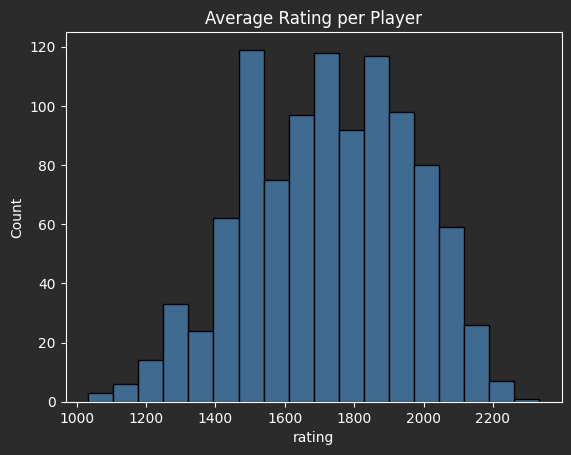

In [467]:
player_avg_rating = train_df.groupby('nickname')['rating'].mean()
sns.histplot(player_avg_rating, color='steelblue')
plt.title('Average Rating per Player')
plt.show()

## 1.7 Numerical Feature Distributions

In [468]:
def plot_numerical_hists(df: pd.DataFrame) -> None:
    numerical_cols = df.select_dtypes(include='number').columns

    df[numerical_cols].hist(bins=30, figsize=(16, 12),
                            layout=(4, 4), color='steelblue',
                            edgecolor='white')
    plt.suptitle('Numerical Feature Distributions', fontsize=16)
    plt.tight_layout()
    plt.show()


Numerical Distributions per Dataset

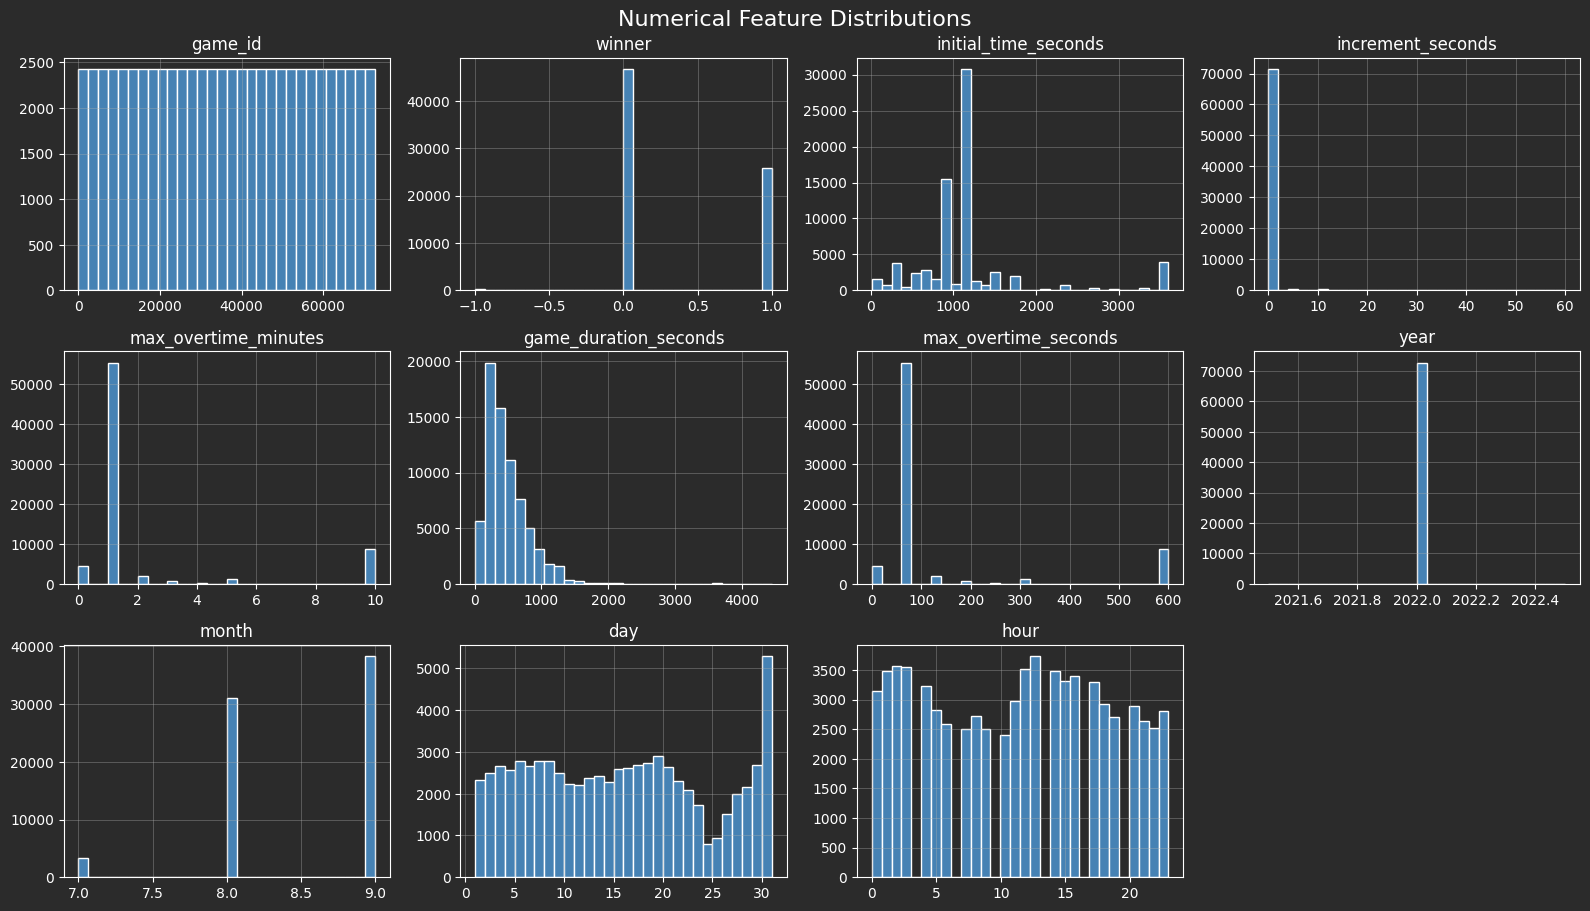

In [469]:
plot_numerical_hists(games_df)

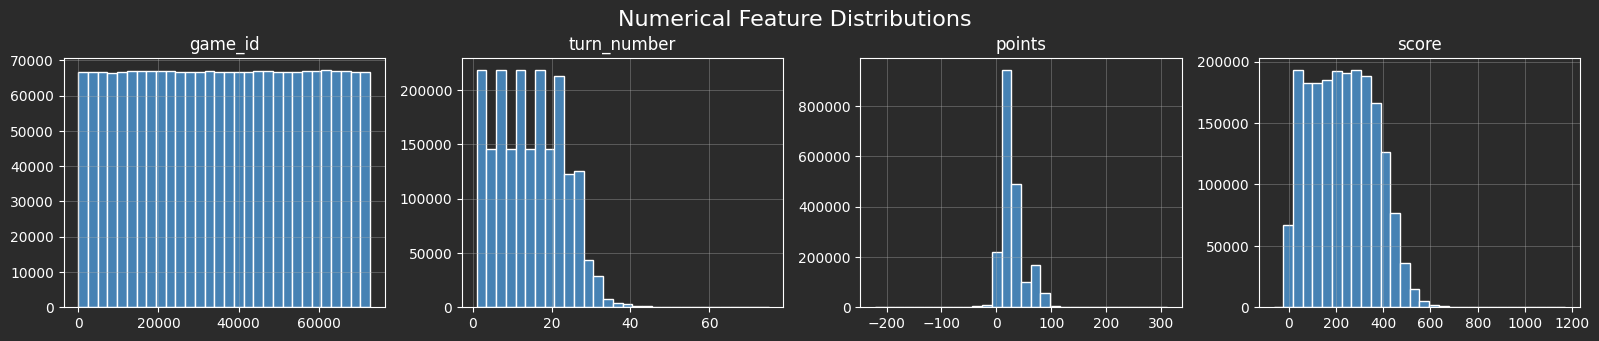

In [470]:
plot_numerical_hists(turns_df)

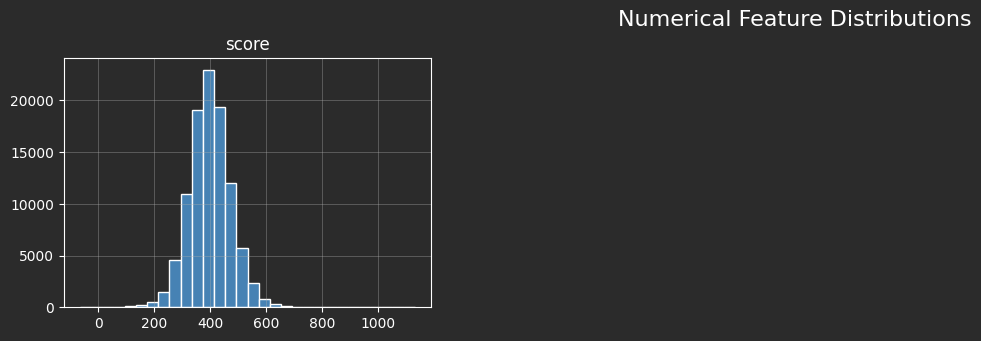

In [471]:
plot_numerical_hists(train_df["score"].to_frame())

## 1.8 Categorical Feature Distributions

In [472]:
def plot_categorical_hists(df: pd.DataFrame) -> None:
    categorical_cols = df.select_dtypes(include='object').columns

    for col in categorical_cols:
        n_unique = df[col].nunique()

        if n_unique <= 20:
            sns.countplot(y=col, data=df,
                          order=df[col].value_counts().index,
                          palette='viridis')
            plt.title(f'Value Counts: {col}')
            plt.show()

/var/folders/31/lj4zgqkn157cdn1z9qhhndmw0000gn/T/ipykernel_61543/4211453981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df,


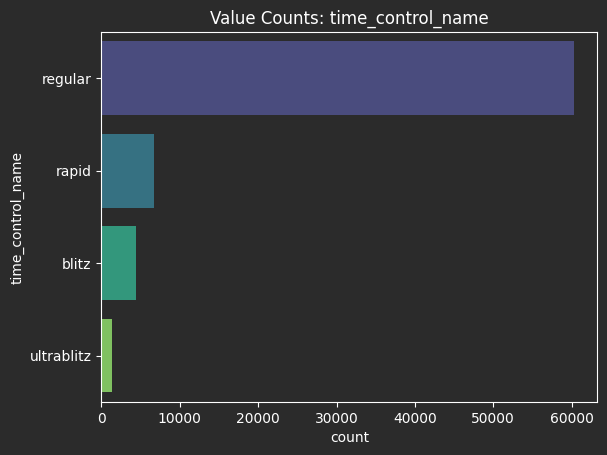

/var/folders/31/lj4zgqkn157cdn1z9qhhndmw0000gn/T/ipykernel_61543/4211453981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df,


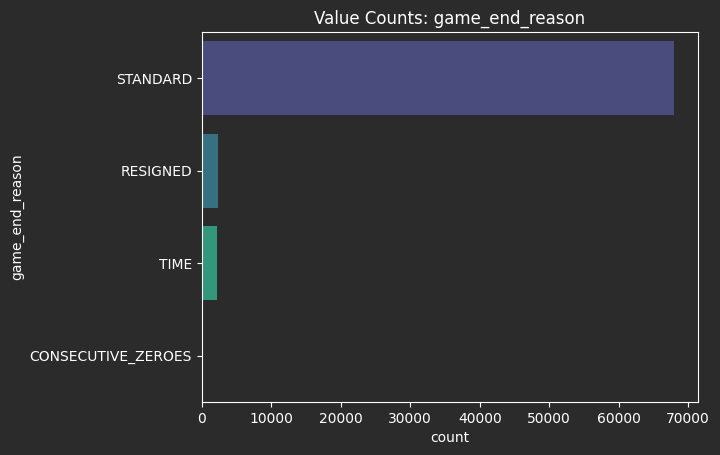

/var/folders/31/lj4zgqkn157cdn1z9qhhndmw0000gn/T/ipykernel_61543/4211453981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df,


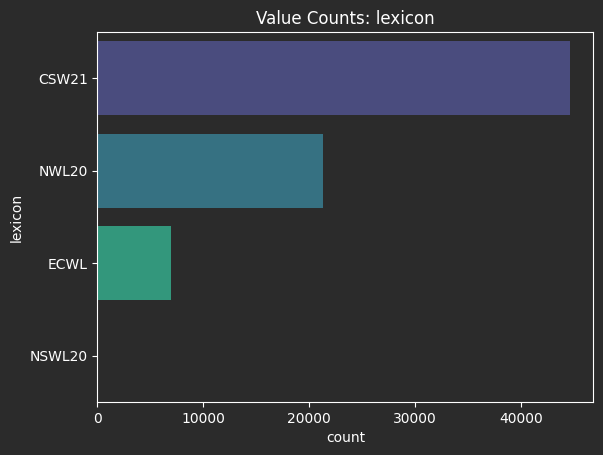

/var/folders/31/lj4zgqkn157cdn1z9qhhndmw0000gn/T/ipykernel_61543/4211453981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df,


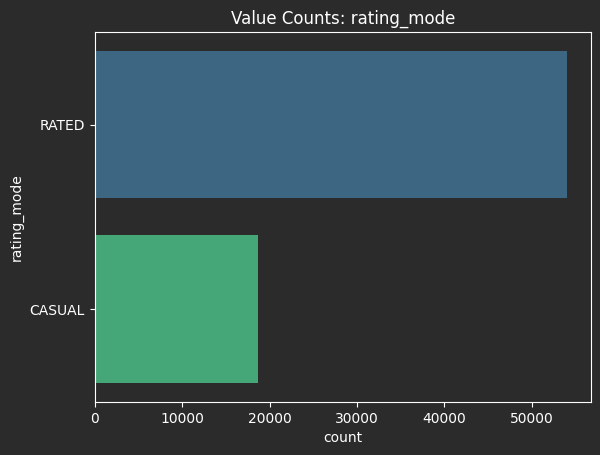

In [473]:
plot_categorical_hists(games_df)

/var/folders/31/lj4zgqkn157cdn1z9qhhndmw0000gn/T/ipykernel_61543/4211453981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df,


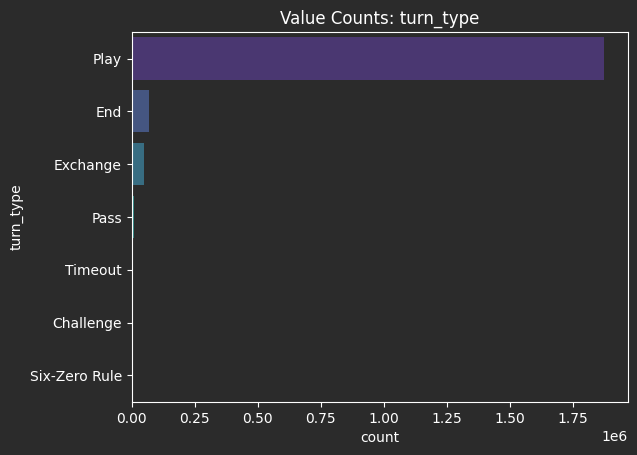

In [474]:
plot_categorical_hists(turns_df)

## 1.9 Correlation Between Numerical Features

In [475]:
def plot_numerical_correlation_matrix(df: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 10))
    numerical_cols = df.select_dtypes(include='number').columns
    corr_matrix = df[numerical_cols].corr()

    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5)
    plt.title('Feature Correlation Matrix')
    plt.show()

### Correlation Matrices per Dataset

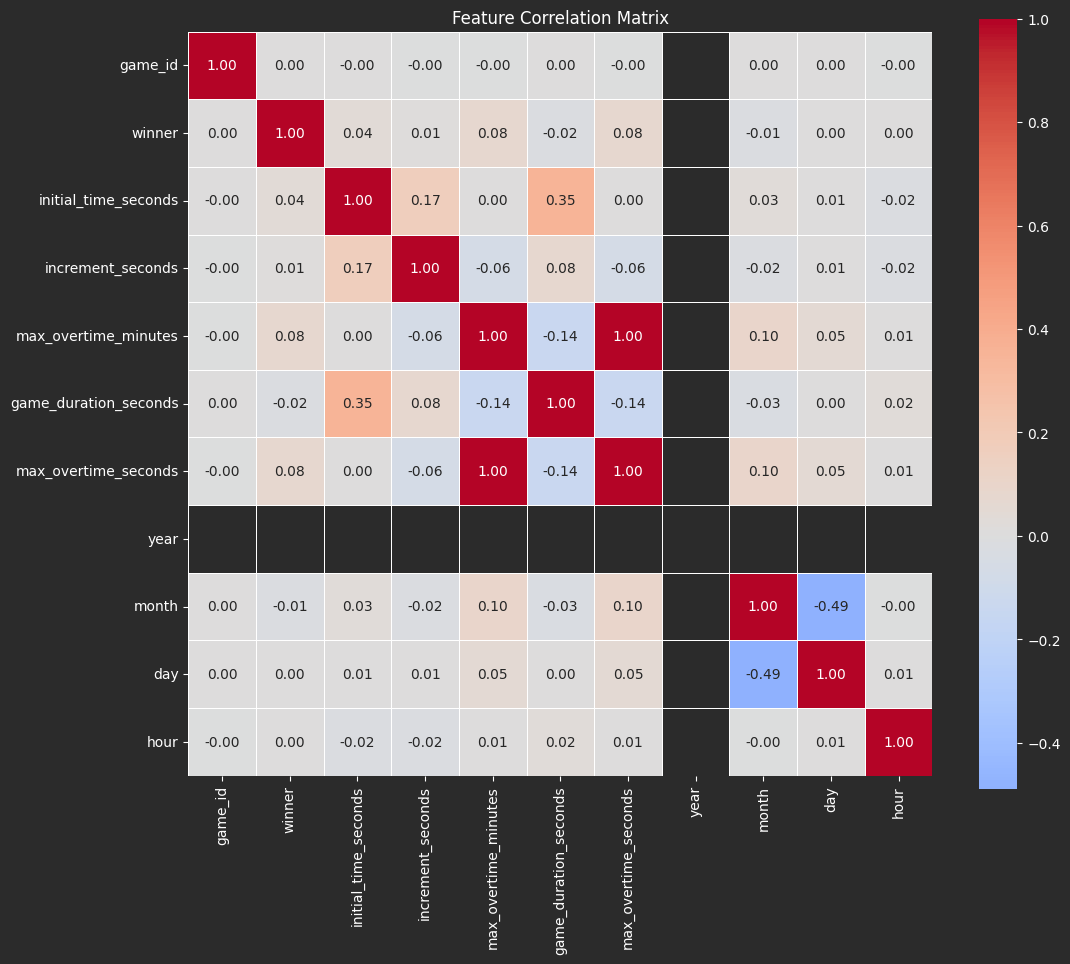

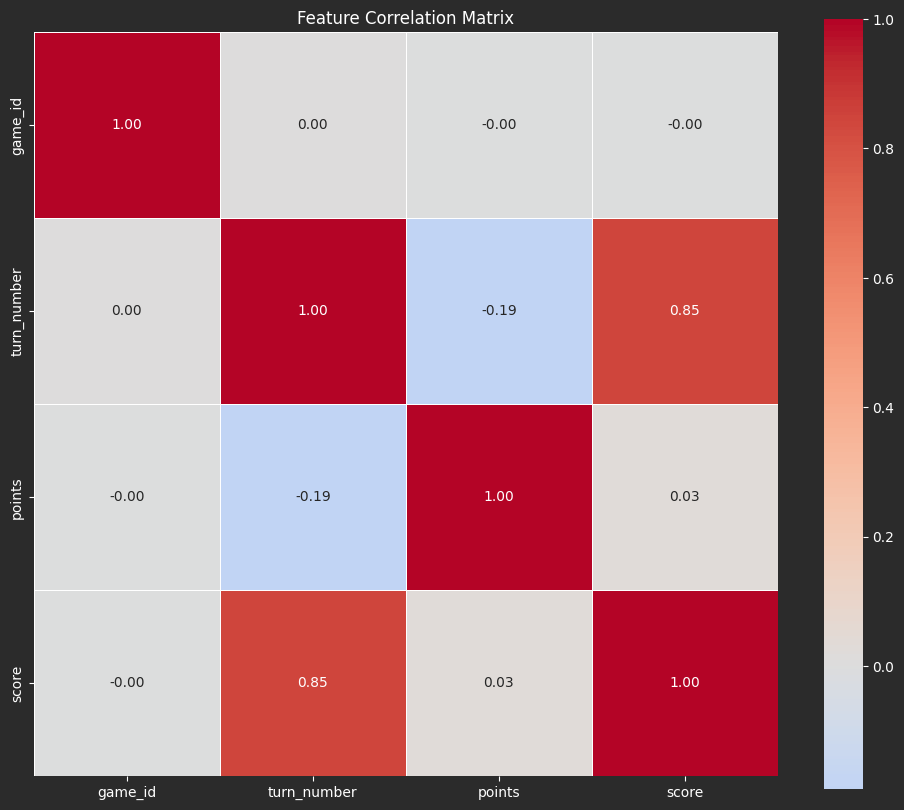

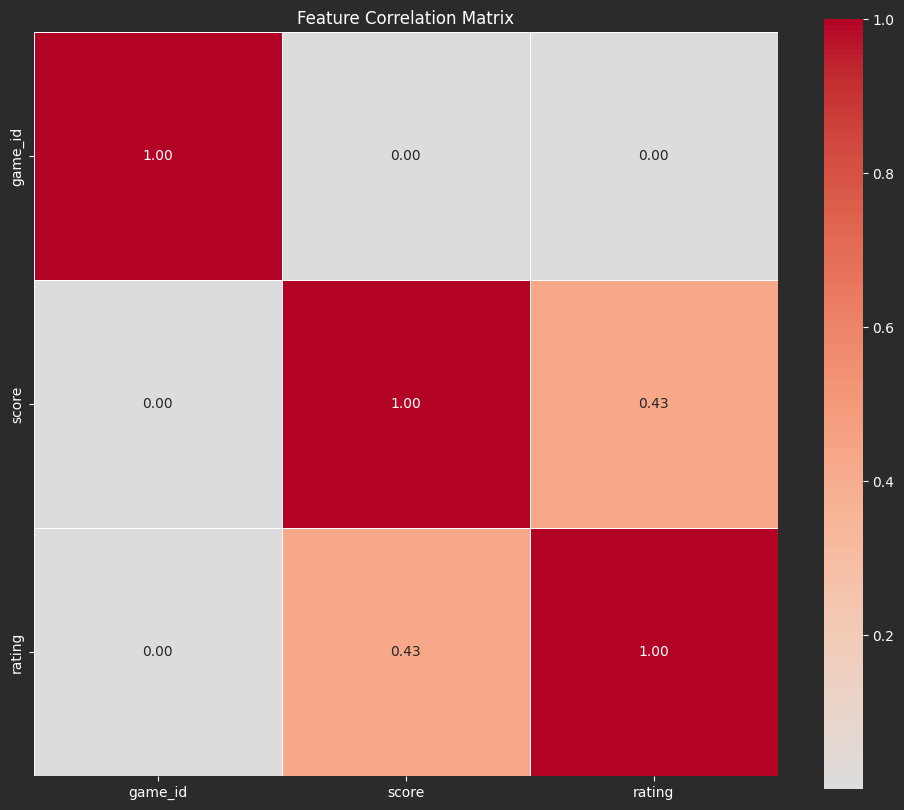

In [476]:
plot_numerical_correlation_matrix(games_df)
plot_numerical_correlation_matrix(turns_df)
plot_numerical_correlation_matrix(train_df)

## 1.10 Merged Dataset

The last turn of each (game, player) carries the final score, so it is kept and joined to the
game-level settings and then to the ratings from `train`. Turn-specific columns that no longer
make sense after the aggregation are dropped.

In [477]:
merged_games_and_turns_df = (
    turns_df
    .sort_values(['game_id', 'turn_number'])
    .drop_duplicates(subset=['game_id', 'nickname'], keep='last')
    .merge(games_df, on='game_id', how='inner')
)
full_df = merged_games_and_turns_df.merge(
    train_df[['game_id', 'nickname', 'rating']],
    on=['game_id', 'nickname'],
    how='left'
)
full_df = full_df.drop(columns=["rack", "location", "move", "turn_type", "max_overtime_minutes", "created_at", "turn_number", "points"])
full_df.head(10)


,game_id,nickname,score,first,time_control_name,game_end_reason,winner,lexicon,initial_time_seconds,increment_seconds,rating_mode,game_duration_seconds,max_overtime_seconds,year,month,day,hour,rating
0,1,BetterBot,335,BetterBot,regular,STANDARD,1,NWL20,1200,0,CASUAL,674.844274,60,2022,8,26,3,1637.0
1,1,stevy,429,BetterBot,regular,STANDARD,1,NWL20,1200,0,CASUAL,674.844274,60,2022,8,26,3,1500.0
2,2,BetterBot,401,Super,regular,STANDARD,1,CSW21,3600,0,RATED,364.214418,60,2022,8,10,19,NaN
3,2,Super,488,Super,regular,STANDARD,1,CSW21,3600,0,RATED,364.214418,60,2022,8,10,19,NaN
4,3,BetterBot,318,BetterBot,regular,STANDARD,1,CSW21,900,0,RATED,492.268262,300,2022,9,4,8,2071.0
5,3,davidavid,440,BetterBot,regular,STANDARD,1,CSW21,900,0,RATED,492.268262,300,2022,9,4,8,1811.0
6,4,Inandoutworker,119,BetterBot,regular,RESIGNED,0,CSW21,3600,0,CASUAL,350.861141,60,2022,9,12,2,1473.0
7,4,BetterBot,478,BetterBot,regular,RESIGNED,0,CSW21,3600,0,CASUAL,350.861141,60,2022,9,12,2,1936.0
8,5,STEEBot,427,STEEBot,regular,STANDARD,0,NWL20,1200,0,CASUAL,642.688722,60,2022,9,6,4,1844.0
9,5,stevy,325,STEEBot,regular,STANDARD,0,NWL20,1200,0,CASUAL,642.688722,60,2022,9,6,4,1500.0


### 1.10.2 Distributions and Correlations on the Merged Dataset

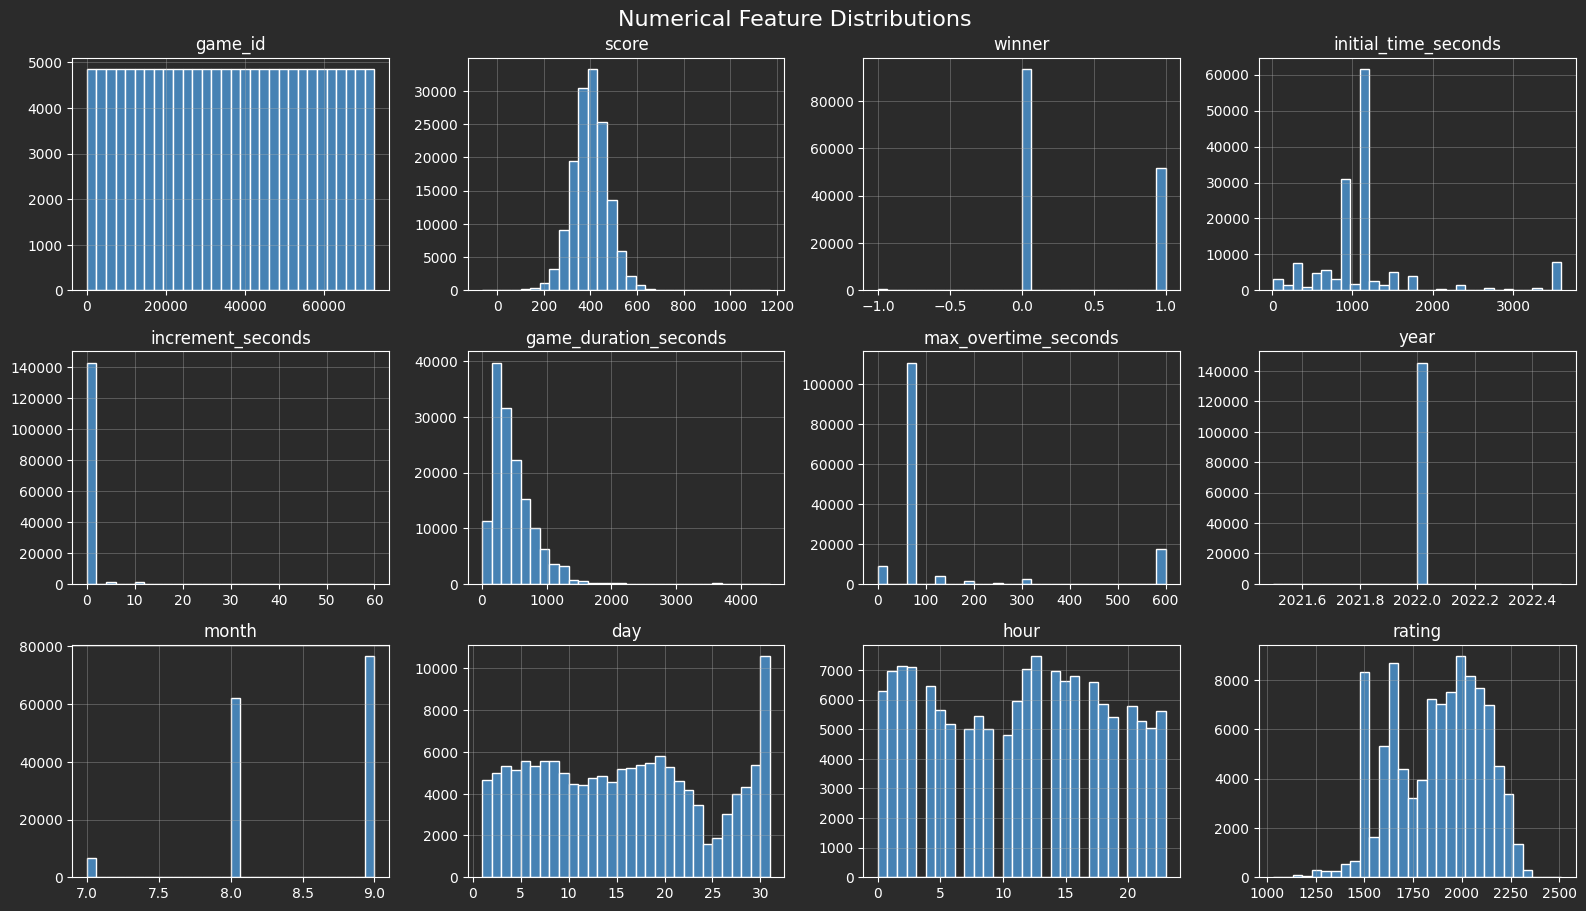

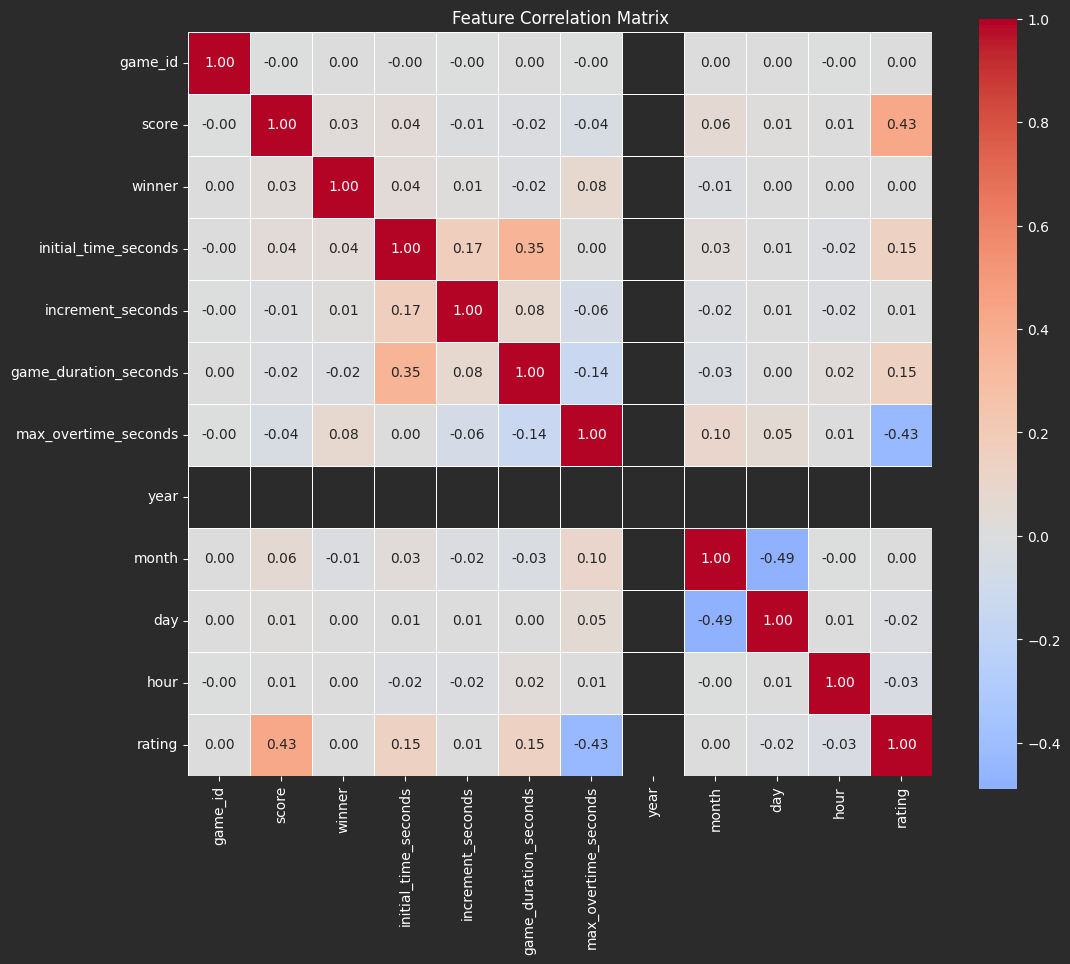

In [478]:
plot_numerical_hists(full_df)
plot_numerical_correlation_matrix(full_df)

## 1.11 Categorical Features vs Rating

Pearson correlation doesn't apply to categorical features, so the correlation ratio is used
instead: 0 means the category carries no information about the rating, 1 means it fully
determines it.

In [479]:
def correlation_ratio(categories, values):
    df = pd.DataFrame({'categories': categories, 'val': values}).dropna()
    categories_means = df.groupby('categories')['val'].mean()
    overall_mean = df['val'].mean()
    ss_between = (df.groupby('categories')['val'].size() * (categories_means - overall_mean) ** 2).sum()
    ss_total = ((df['val'] - overall_mean) ** 2).sum()
    return np.nan if ss_total == 0 else (ss_between / ss_total) ** 0.5

def categorical_vs_target_summary(df, target, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
        categorical_cols = [c for c in categorical_cols if c != target]

    results = []
    for col in categorical_cols:
        sub = df[[col, target]].dropna()
        eta = correlation_ratio(sub[col], sub[target])
        results.append({'feature': col, 'eta': eta})

    return pd.DataFrame(results).sort_values('eta', ascending=False)

### Correlation Ratio of Categorical Features vs Rating

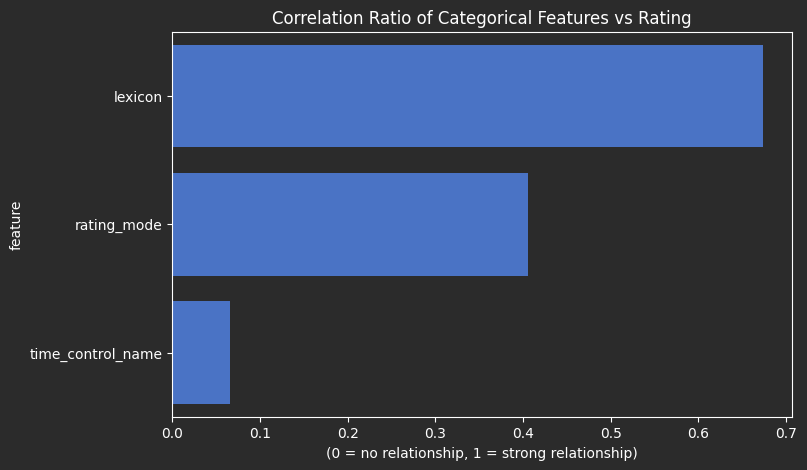

In [480]:
summary = categorical_vs_target_summary(full_df[["lexicon", "rating_mode", "time_control_name", "rating"]], target='rating')
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x='eta', y='feature', order=summary['feature'])
plt.title('Correlation Ratio of Categorical Features vs Rating')
plt.xlabel('(0 = no relationship, 1 = strong relationship)')
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

# Feature Engineering

Move efficiency = points scored divided by the number of tiles placed that turn. `.` marks
letters already on the board, so only newly placed tiles count.

In [481]:
LETTER_VALUES = {
    'A': 1, 'B': 3, 'C': 3, 'D': 2, 'E': 1, 'F': 4, 'G': 2,
    'H': 4, 'I': 1, 'J': 8, 'K': 5, 'L': 1, 'M': 3, 'N': 1,
    'O': 1, 'P': 3, 'Q': 10, 'R': 1, 'S': 1, 'T': 1, 'U': 1,
    'V': 4, 'W': 4, 'X': 8, 'Y': 4, 'Z': 10, '?': 0,
}


def move_tile_value(move):
    if pd.isna(move):
        return np.nan
    value = 0
    for c in move:
        if c == '.':
            continue
        elif c.islower():
            value += 0
        elif c.isalpha():
            value += LETTER_VALUES.get(c.upper(), 0)
    return value


def move_tile_count(move):
    if pd.isna(move):
        return np.nan
    return sum(1 for c in move if c != '.' and c.isalpha())


play_turns = turns_df[turns_df['turn_type'] == 'Play'].copy()
play_turns['tiles_placed_value'] = play_turns['move'].apply(move_tile_value)
play_turns['tiles_placed'] = play_turns['move'].apply(move_tile_count)

play_turns['move_efficiency'] = play_turns['points'] / play_turns['tiles_placed'].replace(0, np.nan)
play_turns.head()

,game_id,turn_number,nickname,rack,location,move,points,score,turn_type,tiles_placed_value,tiles_placed,move_efficiency
0,1,1,BetterBot,DDEGITT,8G,DIG,10,10,Play,5.0,3.0,3.333333
1,1,2,stevy,AEHOPUX,7H,HAP,18,18,Play,8.0,3.0,6.000000
2,1,3,BetterBot,DEELTTU,6I,LUTE,16,26,Play,4.0,4.0,4.000000
3,1,4,stevy,EMORSUX,5K,UM,16,34,Play,4.0,2.0,8.000000
4,1,5,BetterBot,ACDEITU,L5,..DICATE,28,54,Play,9.0,6.0,4.666667


### Feature Engineering : game efficiency
Choosing the denominator: tile value vs tile count
Two ways to normalise the points scored on a turn:

- **by tile value** -- `points / sum of the letter values placed`, which controls for how good the
  letters were.
- **by tile count** -- `points / number of tiles placed`.

Both are computed below on the same rows and compared.

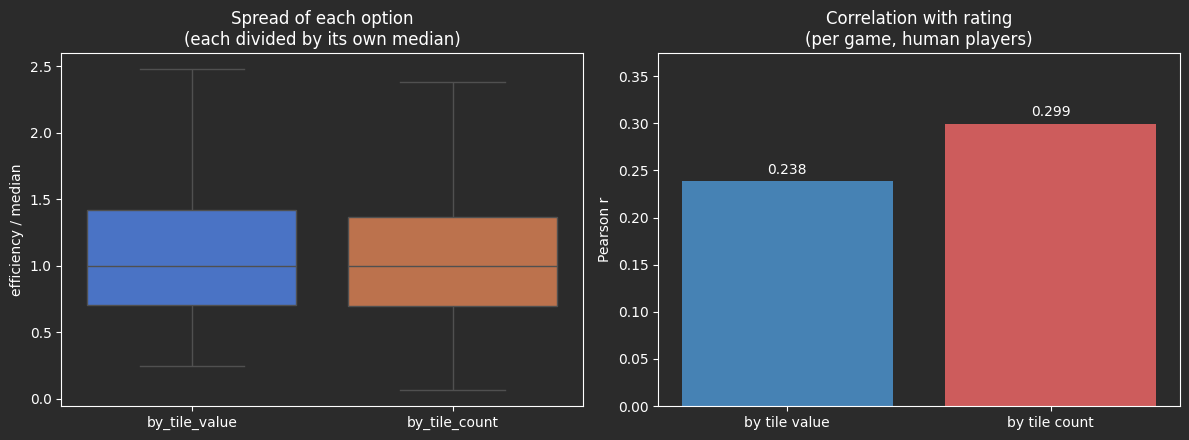

In [482]:
BOT_NICKNAMES = ['BetterBot', 'STEEBot', 'HastyBot']

efficiency_options = pd.DataFrame({
    'game_id': play_turns['game_id'],
    'nickname': play_turns['nickname'],
    'by_tile_value': play_turns['points'] / play_turns['tiles_placed_value'].replace(0, np.nan),
    'by_tile_count': play_turns['points'] / play_turns['tiles_placed'].replace(0, np.nan),
})

per_game_options = (
    efficiency_options.groupby(['game_id', 'nickname'])[['by_tile_value', 'by_tile_count']]
    .mean()
    .reset_index()
    .merge(train_df[['game_id', 'nickname', 'rating']], on=['game_id', 'nickname'], how='inner')
)
per_game_options = per_game_options[~per_game_options['nickname'].isin(BOT_NICKNAMES)]
OPTIONS = ['by_tile_value', 'by_tile_count']
correlations = {option: per_game_options[option].corr(per_game_options['rating']) for option in OPTIONS}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

normalised = efficiency_options[OPTIONS] / efficiency_options[OPTIONS].median()
sns.boxplot(data=normalised, ax=axes[0], showfliers=False)
axes[0].set_title('Spread of each option\n(each divided by its own median)')
axes[0].set_ylabel('efficiency / median')

vals = [correlations[option] for option in OPTIONS]
bars = axes[1].bar(['by tile value', 'by tile count'], vals, color=['steelblue', 'indianred'])
axes[1].set_title('Correlation with rating\n(per game, human players)')
axes[1].set_ylabel('Pearson r')
axes[1].set_ylim(0, max(vals) * 1.25)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.008, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

##### Dividing by tile count is the option used above: it tracks rating better (0.299 vs 0.238) and its distribution is less skewed (1.90 vs 2.34).

### Aggregating Efficiency per Player

Averaged per game, then per player, keeping human players only (bots have fixed ratings).

In [483]:
player_game_efficiency = (
    play_turns.groupby(['game_id', 'nickname'])['move_efficiency']
    .mean()
    .reset_index()
    .rename(columns={'move_efficiency': 'avg_move_efficiency'})
)

final_score = (
    turns_df.sort_values(['game_id', 'turn_number'])
    .drop_duplicates(subset=['game_id', 'nickname'], keep='last')
    [['game_id', 'nickname', 'score']]
)

efficiency_per_game_df = (
    player_game_efficiency
    .rename(columns={'avg_move_efficiency': 'game_efficiency'})
    .merge(final_score, on=['game_id', 'nickname'], how='left')
    .merge(train_df[['game_id', 'nickname', 'rating']], on=['game_id', 'nickname'], how='left')
)

feature_engineered_df = efficiency_per_game_df.merge(
    games_df,
    on='game_id',
    how='left',
)
feature_engineered_df.drop(columns=['year', 'month', 'day', 'hour', 'increment_seconds', 'game_end_reason', 'created_at', 'max_overtime_minutes', 'time_control_name', 'first'], inplace=True)
feature_engineered_df.head()

,game_id,nickname,game_efficiency,score,rating,winner,lexicon,initial_time_seconds,rating_mode,game_duration_seconds,max_overtime_seconds
0,1,BetterBot,6.526740,335,1637.0,1,NWL20,1200,CASUAL,674.844274,60
1,1,stevy,9.163004,429,1500.0,1,NWL20,1200,CASUAL,674.844274,60
2,2,BetterBot,7.629563,401,NaN,1,CSW21,3600,RATED,364.214418,60
3,2,Super,10.553463,488,NaN,1,CSW21,3600,RATED,364.214418,60
4,3,BetterBot,6.895040,318,2071.0,1,CSW21,900,RATED,492.268262,300


##### added game efficiency as a feature

### Bot visualizations

nickname
STEEBot      24916
BetterBot    24244
HastyBot     23613
Name: count, dtype: int64


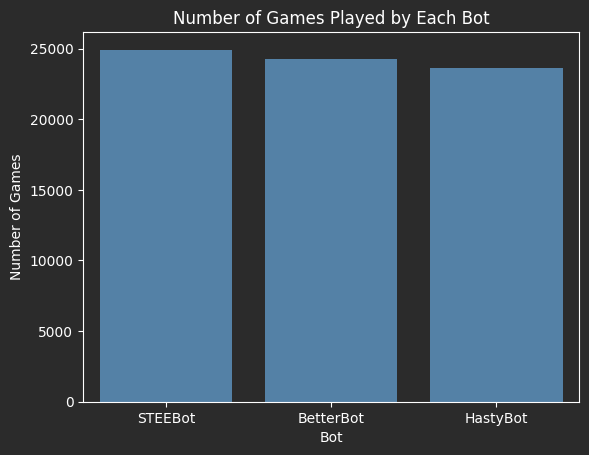

In [484]:
bot_names = ['BetterBot', 'STEEBot', 'HastyBot']

bot_turns = turns_df[turns_df['nickname'].isin(bot_names)]
bot_games = bot_turns.drop_duplicates(subset=['game_id', 'nickname'])

bot_counts = bot_games['nickname'].value_counts()
print(bot_counts)

sns.barplot(x=bot_counts.index, y=bot_counts.values, color='steelblue')
plt.title('Number of Games Played by Each Bot')
plt.xlabel('Bot')
plt.ylabel('Number of Games')
plt.show()


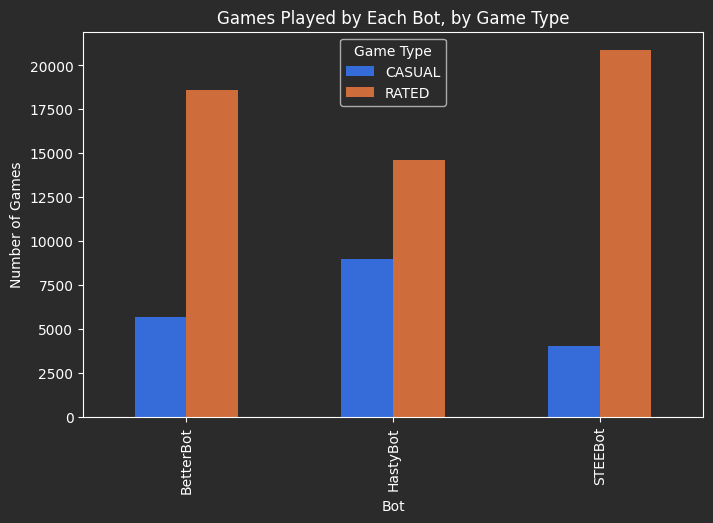

In [485]:
merged_bots = bot_games.merge(
    games_df[['game_id', 'rating_mode']],
    on='game_id',
    how='left'
)
bot_type_counts = merged_bots.groupby(['nickname', 'rating_mode']).size().unstack(fill_value=0)

bot_type_counts.plot(kind='bar', figsize=(8, 5))
plt.title('Games Played by Each Bot, by Game Type')
plt.xlabel('Bot')
plt.ylabel('Number of Games')
plt.legend(title='Game Type')
plt.show()

In [486]:
bot_features = (
    feature_engineered_df[feature_engineered_df['nickname'].isin(bot_names)]
    [['game_id', 'nickname', 'rating']]
    .rename(columns={'nickname': 'bot_name', 'rating': 'bot_rating'})
)

feature_engineered_df = (
    feature_engineered_df[~feature_engineered_df['nickname'].isin(bot_names)]
    .merge(bot_features, on='game_id', how='left')
    .reset_index(drop=True)
)
feature_engineered_df.head()

,game_id,nickname,game_efficiency,score,rating,winner,lexicon,initial_time_seconds,rating_mode,game_duration_seconds,max_overtime_seconds,bot_name,bot_rating
0,1,stevy,9.163004,429,1500.0,1,NWL20,1200,CASUAL,674.844274,60,BetterBot,1637.0
1,2,Super,10.553463,488,NaN,1,CSW21,3600,RATED,364.214418,60,BetterBot,NaN
2,3,davidavid,8.998535,440,1811.0,1,CSW21,900,RATED,492.268262,300,BetterBot,2071.0
3,4,Inandoutworker,5.791667,119,1473.0,0,CSW21,3600,CASUAL,350.861141,60,BetterBot,1936.0
4,5,stevy,8.878571,325,1500.0,0,NWL20,1200,CASUAL,642.688722,60,STEEBot,1844.0


                  mean         std  count
bot_name                                 
BetterBot  1767.031809  217.453725  16599
HastyBot   1743.023542  252.706699  17331
STEEBot    1863.843196  195.487737  16460
0.22685074124945237


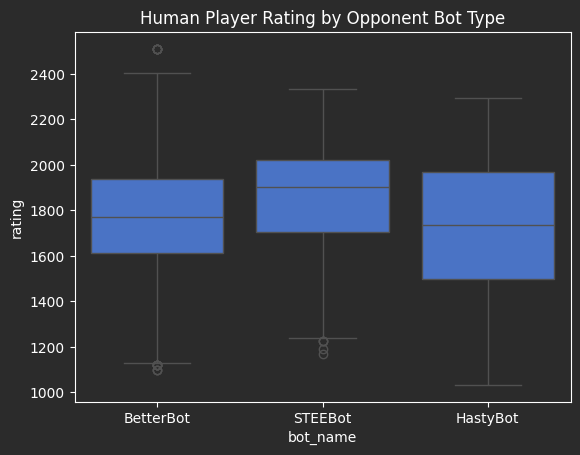

In [487]:
bot_vs_human = feature_engineered_df.dropna(subset=['rating'])
print(bot_vs_human.groupby('bot_name')['rating'].agg(['mean', 'std', 'count']))

print(correlation_ratio(bot_vs_human['bot_name'], bot_vs_human['rating']))

sns.boxplot(x='bot_name', y='rating', data=bot_vs_human)
plt.title('Human Player Rating by Opponent Bot Type')
plt.show()

##### we can see that if we check the overall data, players rating on avg are higher on STEEBot, then BetterBot and last HastyBot, which doesn't make a lot of sense because Hastybot is the hardest bot. It makes sense if we consider the fact that Hastybot was played a lot in casual games.

In [488]:
rated_only = bot_vs_human[bot_vs_human['rating_mode'] == 'RATED']

print(rated_only.groupby('bot_name')['rating'].agg(['mean', 'std', 'count']))

                  mean         std  count
bot_name                                 
BetterBot  1792.932692  209.285470  13609
HastyBot   1912.253423  199.779110   9056
STEEBot    1886.469589  187.317812  13367


##### now, if we check only rated games, we see that HastyBot has the higher human avg rating, then SteeBot and then BetterBot, which corresponds to the level of each bot

In [489]:
casual_only = bot_vs_human[bot_vs_human['rating_mode'] == 'CASUAL']

print(casual_only.groupby('bot_name')['rating'].agg(['mean', 'std', 'count']))

                  mean         std  count
bot_name                                 
BetterBot  1649.143813  214.975991   2990
HastyBot   1557.821631  156.296489   8275
STEEBot    1766.058843  199.922850   3093


##### in casual we can see the rating is not corresponding with difficulty of the bot

In [490]:
bot_vs_human_full = bot_vs_human.dropna(subset=['bot_rating'])

for mode, group in bot_vs_human_full.groupby('rating_mode'):
    print(mode)
    print(group[['bot_rating', 'rating']].corr())

CASUAL
            bot_rating    rating
bot_rating    1.000000  0.703253
rating        0.703253  1.000000
RATED
            bot_rating    rating
bot_rating    1.000000  0.558191
rating        0.558191  1.000000


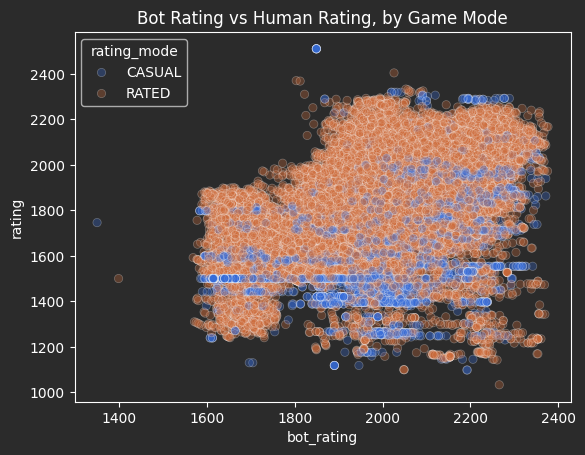

In [491]:
sns.scatterplot(x='bot_rating', y='rating', hue='rating_mode', data=bot_vs_human_full, alpha=0.3)
plt.title('Bot Rating vs Human Rating, by Game Mode')
plt.show()

##### we can see good correlation between bot rating and player rating. we add bot rating a feature

In [492]:
feature_engineered_df = feature_engineered_df.drop(columns=['winner', 'nickname'], errors='ignore')
train_feature_engineering_df = feature_engineered_df[feature_engineered_df.rating.notna()]


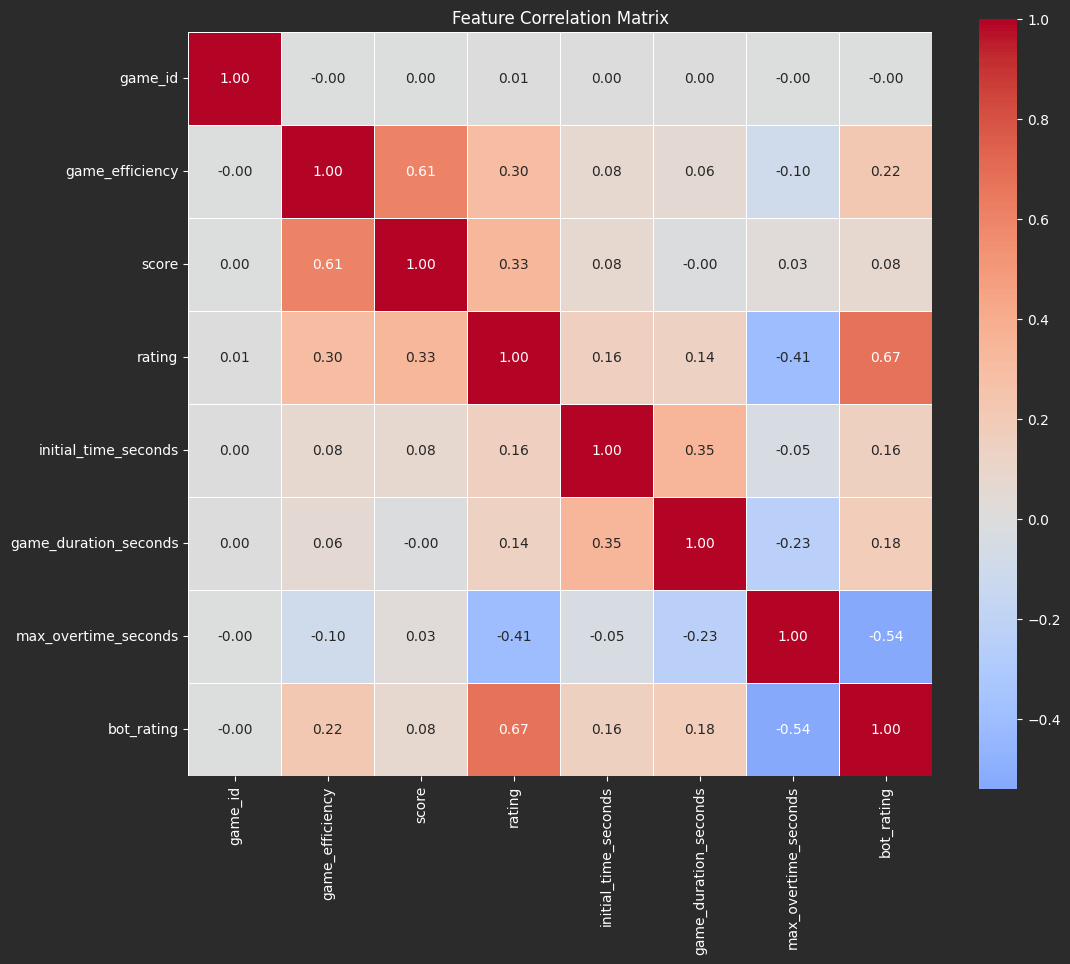

,game_id,game_efficiency,score,rating,lexicon,initial_time_seconds,rating_mode,game_duration_seconds,max_overtime_seconds,bot_name,bot_rating
0,1,9.163004,429,1500.0,NWL20,1200,CASUAL,674.844274,60,BetterBot,1637.0
2,3,8.998535,440,1811.0,CSW21,900,RATED,492.268262,300,BetterBot,2071.0
3,4,5.791667,119,1473.0,CSW21,3600,CASUAL,350.861141,60,BetterBot,1936.0
4,5,8.878571,325,1500.0,NWL20,1200,CASUAL,642.688722,60,STEEBot,1844.0
5,6,7.876389,378,2029.0,CSW21,900,RATED,426.950541,60,STEEBot,2143.0


In [493]:
plot_numerical_correlation_matrix(train_feature_engineering_df)
train_feature_engineering_df.head()

## Feature Selection: Forward Selection

In [503]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

FEATURES = ['game_efficiency', 'score', 'initial_time_seconds', 'game_duration_seconds',
            'max_overtime_seconds', 'bot_rating', 'lexicon', 'rating_mode', 'bot_name']
CATEGORICAL = ['lexicon', 'rating_mode', 'bot_name']

selection_rows = train_feature_engineering_df.dropna(subset=['rating'] + FEATURES)
X = selection_rows[FEATURES]
y = selection_rows['rating']

model = Pipeline([
    ('encode', ColumnTransformer([
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'),
         make_column_selector(dtype_include=object)),
        ('numeric', StandardScaler(), make_column_selector(dtype_include=np.number)),
    ])),
    ('ridge', Ridge(alpha=10.0)),
])

CV = KFold(n_splits=5, shuffle=True, random_state=0)
SCORING = 'neg_root_mean_squared_error'
selected, remaining, best = [], list(FEATURES), float(y.std())
print(f'start, no features:  CV RMSE {best:7.2f}')
while remaining:
    scores = {feature: -cross_val_score(model, X[selected + [feature]], y, cv=CV, scoring=SCORING).mean()
              for feature in remaining}
    pick = min(scores, key=scores.get)
    change = scores[pick] - best
    selected.append(pick)
    remaining.remove(pick)
    best = scores[pick]
    print(f'  step {len(selected)}: {pick:22s} CV RMSE {best:7.2f}  ({change:+.2f})')

start, no features:  CV RMSE  229.64
  step 1: bot_rating             CV RMSE  169.58  (-60.06)
  step 2: score                  CV RMSE  156.62  (-12.96)
  step 3: lexicon                CV RMSE  149.48  (-7.14)
  step 4: rating_mode            CV RMSE  145.33  (-4.16)
  step 5: initial_time_seconds   CV RMSE  144.10  (-1.23)
  step 6: bot_name               CV RMSE  143.60  (-0.50)
  step 7: game_efficiency        CV RMSE  143.52  (-0.08)
  step 8: max_overtime_seconds   CV RMSE  143.47  (-0.06)
  step 9: game_duration_seconds  CV RMSE  143.42  (-0.05)


##### we can see how every feature is significant to the current model (linear regression with ridge regularization) affects the RMSE

## Feature Selection: Backward Elimination

Backward elimination works the other way round: it starts with every feature and repeatedly
removes whichever one the model misses least, until only one is left.

In [496]:
kept = list(FEATURES)
backward_best = -cross_val_score(model, X, y, cv=CV, scoring=SCORING).mean()
print(f'start, all {len(kept)} features: CV RMSE {backward_best:7.2f}')

while len(kept) > 1:
    scores = {
        feature: -cross_val_score(
            model, X[[c for c in kept if c != feature]], y, cv=CV, scoring=SCORING
        ).mean()
        for feature in kept
    }
    drop = min(scores, key=scores.get)
    change = scores[drop] - backward_best
    kept.remove(drop)
    backward_best = scores[drop]
    print(f'  drop {drop:22s} -> {len(kept)} left, CV RMSE {backward_best:7.2f}  ({change:+.2f})')

start, all 9 features: CV RMSE  143.42
  drop game_duration_seconds  -> 8 left, CV RMSE  143.47  (+0.05)
  drop max_overtime_seconds   -> 7 left, CV RMSE  143.52  (+0.06)
  drop game_efficiency        -> 6 left, CV RMSE  143.60  (+0.08)
  drop bot_name               -> 5 left, CV RMSE  144.10  (+0.50)
  drop initial_time_seconds   -> 4 left, CV RMSE  145.33  (+1.23)
  drop rating_mode            -> 3 left, CV RMSE  149.48  (+4.16)
  drop lexicon                -> 2 left, CV RMSE  156.62  (+7.14)
  drop score                  -> 1 left, CV RMSE  169.58  (+12.96)


##### game efficiency gave upsetting results. Trying to make new features that may correlate better to how good a player is, based on turns data.
### Feature Engineering : average tiles laid per turn

In [497]:
tiles_per_turn = (
    play_turns[~play_turns['nickname'].isin(bot_names)]
    .groupby('game_id')['tiles_placed']
    .mean()
    .rename('tiles_placed_avg')
    .reset_index()
)

feature_engineered_df = (
    feature_engineered_df
    .drop(columns=['tiles_placed_avg'], errors='ignore')
    .merge(tiles_per_turn, on='game_id', how='left')
)

train_feature_engineering_df = feature_engineered_df[feature_engineered_df['rating'].notna()]
train_feature_engineering_df.head()

,game_id,game_efficiency,score,rating,lexicon,initial_time_seconds,rating_mode,game_duration_seconds,max_overtime_seconds,bot_name,bot_rating,tiles_placed_avg
0,1,9.163004,429,1500.0,NWL20,1200,CASUAL,674.844274,60,BetterBot,1637.0,3.615385
2,3,8.998535,440,1811.0,CSW21,900,RATED,492.268262,300,BetterBot,2071.0,3.769231
3,4,5.791667,119,1473.0,CSW21,3600,CASUAL,350.861141,60,BetterBot,1936.0,1.583333
4,5,8.878571,325,1500.0,NWL20,1200,CASUAL,642.688722,60,STEEBot,1844.0,2.857143
5,6,7.876389,378,2029.0,CSW21,900,RATED,426.950541,60,STEEBot,2143.0,4.083333


### Feature Engineering : Bingo frequency

In [498]:
bingo_per_game = (
    play_turns[~play_turns['nickname'].isin(bot_names)]
    .assign(is_bingo=lambda df: df['tiles_placed'] == 7)
    .groupby('game_id')['is_bingo']
    .mean()
    .rename('bingo_rate')
    .reset_index()
)

feature_engineered_df = (
    feature_engineered_df
    .drop(columns=['bingo_rate'], errors='ignore')
    .merge(bingo_per_game, on='game_id', how='left')
)

train_feature_engineering_df = feature_engineered_df[feature_engineered_df['rating'].notna()]
train_feature_engineering_df.head()

,game_id,game_efficiency,score,rating,lexicon,initial_time_seconds,rating_mode,game_duration_seconds,max_overtime_seconds,bot_name,bot_rating,tiles_placed_avg,bingo_rate
0,1,9.163004,429,1500.0,NWL20,1200,CASUAL,674.844274,60,BetterBot,1637.0,3.615385,0.153846
2,3,8.998535,440,1811.0,CSW21,900,RATED,492.268262,300,BetterBot,2071.0,3.769231,0.076923
3,4,5.791667,119,1473.0,CSW21,3600,CASUAL,350.861141,60,BetterBot,1936.0,1.583333,0.000000
4,5,8.878571,325,1500.0,NWL20,1200,CASUAL,642.688722,60,STEEBot,1844.0,2.857143,0.000000
5,6,7.876389,378,2029.0,CSW21,900,RATED,426.950541,60,STEEBot,2143.0,4.083333,0.000000


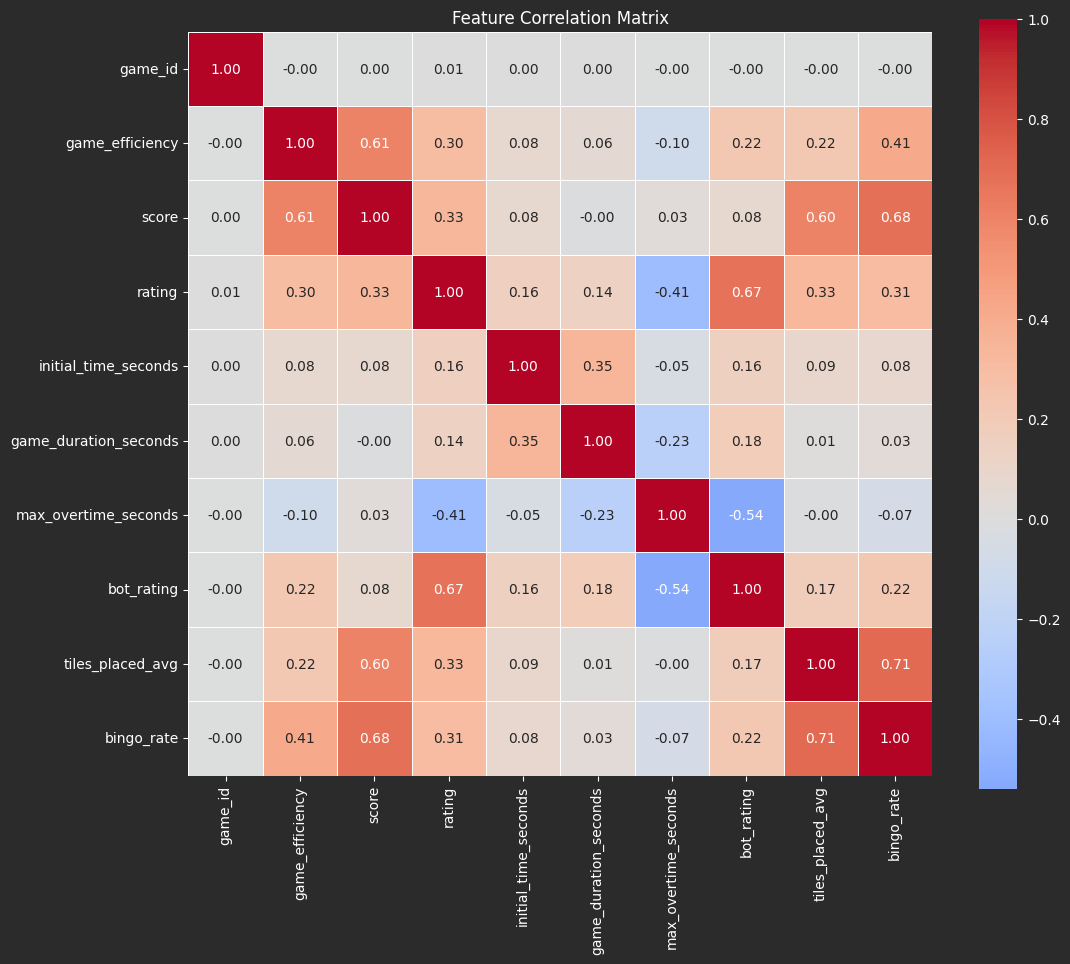

In [499]:
plot_numerical_correlation_matrix(train_feature_engineering_df)

In [500]:
train_feature_engineering_df = feature_engineered_df[feature_engineered_df['rating'].notna()].copy()
test_feature_engineering_df  = feature_engineered_df[feature_engineered_df['rating'].isna()].copy()

### Forward selection with the engineered features

In [502]:
FEATURES_NOW = [column for column in train_feature_engineering_df.columns
                if column not in ('game_id', 'rating')]
rows_now = train_feature_engineering_df.dropna(subset=['rating'] + FEATURES_NOW)
X_now, y_now = rows_now[FEATURES_NOW], rows_now['rating']

chosen, left = [], list(FEATURES_NOW)
best_now = float(y_now.std())
print(f'start, no features:  CV RMSE {best_now:7.2f}')
while left:
    scores = {feature: -cross_val_score(model, X_now[chosen + [feature]], y_now,
                                  cv=CV, scoring=SCORING).mean()
              for feature in left}
    pick = min(scores, key=scores.get)
    change = scores[pick] - best_now
    chosen.append(pick)
    left.remove(pick)
    best_now = scores[pick]
    print(f'  step {len(chosen)}: {pick:22s} CV RMSE {best_now:7.2f}  ({change:+.2f})')

start, no features:  CV RMSE  229.64
  step 1: bot_rating             CV RMSE  169.58  (-60.06)
  step 2: score                  CV RMSE  156.62  (-12.96)
  step 3: lexicon                CV RMSE  149.48  (-7.14)
  step 4: rating_mode            CV RMSE  145.33  (-4.16)
  step 5: tiles_placed_avg       CV RMSE  143.01  (-2.32)
  step 6: initial_time_seconds   CV RMSE  141.74  (-1.27)
  step 7: bingo_rate             CV RMSE  140.98  (-0.76)
  step 8: bot_name               CV RMSE  140.43  (-0.55)
  step 9: max_overtime_seconds   CV RMSE  140.35  (-0.07)
  step 10: game_efficiency        CV RMSE  140.30  (-0.06)
  step 11: game_duration_seconds  CV RMSE  140.24  (-0.06)


##### game_efficiency barely contributes to the model. W can see good contribution by the newly added engineered features